# Satisfaction Analysis base on the Stack Overflow 2025 Survey Data.
In this current notebook, we will upload the stack overflow survery result data and analyse it.
The first step will be to upload it, and analyse it's content.
Then, we will have to clean it, by managing the empty values and filtering out irrelevant data.
We will then be able to create a ML model in order to predict the job satisfaction based on different features.

In [59]:
# Let's first import everything we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
%matplotlib inline

## Business Understanding
We would like to know how the job satisfaction is related to other features. 
1) Is it really the compensation rate that is affecting the job satisfaction?
2) Does the mindset have any impact on that?
3) Does AI shows some tendency on the job satisfaction ?

In [60]:
# Load raw dataset
df = pd.read_csv('./survey_results_public.csv')
# Let's find out what this data contains, and what questions we could have by checking the data.
df.head()

C:\Users\felix.morel\AppData\Local\Temp\ipykernel_32432\2990157293.py:2: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./survey_results_public.csv')


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning new coding techniques or programming language","Online Courses or Certification (includes all media types);Other online resources (e.g. standard search, forum, online community)","Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning new coding techniques or programming language","Online Courses or Certification (includes all media types);Other online resources (e.g. standard search, forum, online community);Books / Physical media;Videos (not associated with specific online course or certification);Stack Overflow or Stack Exchange","Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to fully understand something;When I want to learn best practices;When I want to compare different solutions;When I have ethical or security concerns about code,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-employed",None of the above,10.0,"Yes, I am not new to coding but am learning new coding techniques or programming language",Online Courses or Certification (includes all media types);Videos (not associated with specific online course or certification);Technical documentation (is generated for/by the tool or system),"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to fully understand something;When I want to learn best practices;When I have ethical or security concerns about code;When I’m stuck and can’t explain the problem,"Understand how things actually work, problem solving, and algorithms",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning new coding techniques or programming language","Other online resources (e.g. standard search, forum, online community);Videos (not associated with specific online course or certification);Stack Overflow or Stack Exchange;Technical documentation (is generated for/by the tool or system);AI CodeGen tools or AI-enabled apps","Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to fully understand something;When I have ethical or security concerns about code;When I’m stuck and can’t explain the problem,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-employed","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn new coding techniques or programming languages",NaN,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the task correctly",60000.0,7.0


## Data understanding

In [61]:
# Let's try to find outliers and statistics about the numerical columns
df.describe()

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,...,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,...,5.718355,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,...,2.628016,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.205960e+05,8.000000
max,49191.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000


This gives us information about statistics of numerical columns. We now that we have 49191 answers. We see that the average of job satisfaction is 7.2, but for the rest it is complicate to find more answers here. We need to understand the meaning of each question. This is why we have to upload another CSV to provide the mapping between the question and the question id.

In [62]:
#Import the questions to be able to map them with the ids.
schema = pd.read_csv('./survey_results_schema.csv')
pd.set_option('display.max_rows', 200) 
pd.set_option('display.max_colwidth', None)  # show full question text without truncation
schema[['qname', 'question', 'sub']]

,qname,question,sub
0,TechEndorse_1,What attracts you to a technology or causes you to endorse it (most to least important)?,AI integration or AI Agent capabilities
1,TechEndorse_2,What attracts you to a technology or causes you to endorse it (most to least important)?,Easy-to-use API
2,TechEndorse_3,What attracts you to a technology or causes you to endorse it (most to least important)?,Robust and complete API
3,TechEndorse_4,What attracts you to a technology or causes you to endorse it (most to least important)?,Customizable and manageable codebase
4,TechEndorse_5,What attracts you to a technology or causes you to endorse it (most to least important)?,Reputation for quality
5,TechEndorse_6,What attracts you to a technology or causes you to endorse it (most to least important)?,Connected to an open-source project
6,TechEndorse_7,What attracts you to a technology or causes you to endorse it (most to least important)?,Good brand and public image
7,TechEndorse_8,What attracts you to a technology or causes you to endorse it (most to least important)?,Reliability and low latency
8,TechEndorse_9,What attracts you to a technology or causes you to endorse it (most to least important)?,Costs are manageable
9,TechEndorse_13,What attracts you to a technology or causes you to endorse it (most to least important)?,Other (please specify):


In [63]:
#Find the definitaion of specific question:
qname='JobSat'
schema['full_question'] = schema['question']  + schema['sub'].fillna('')
display (schema[schema['qname'].str.contains(qname, case=False)][['qname', 'full_question']])

display (df[qname].value_counts().head(5)) # provides the 5 most common answers


,qname,full_question
22,JobSatPoints_1,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):Control over the level of quality in projects"
23,JobSatPoints_2,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):Autonomy and trust to manage your own tasks"
24,JobSatPoints_16,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):You like your manager"
25,JobSatPoints_3,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):Collaboration and support from a team"
26,JobSatPoints_4,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):Expert mentors"
27,JobSatPoints_5,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):Opportunities to mentor and lead junior-level coworkers"
28,JobSatPoints_6,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):Developing specialized expertise"
29,JobSatPoints_7,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):Solving real-world problems"
30,JobSatPoints_8,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):Job stability and career growth with a single employer"
31,JobSatPoints_9,"Rank the following attributes of your current professional job in technology according to those that contribute your job satisfaction so that the first is the most important, last is least important (if you just started a new job, consider the job you spent the most time at in the past year):Innovation through solving challenging and complex problems"


JobSat
8.0     6972
7.0     5590
9.0     3598
6.0     3230
10.0    2924
Name: count, dtype: int64

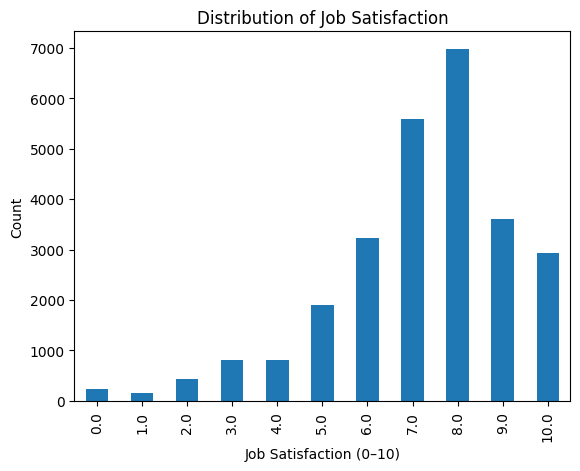

In [64]:
# Check target variable values
counts = df['JobSat'].value_counts().sort_index()

counts.plot(kind='bar')
plt.xlabel('Job Satisfaction (0–10)')
plt.ylabel('Count')
plt.title('Distribution of Job Satisfaction')
plt.show()

We see that the result are centered around 7 to 9 score, and is not equally splitted. However, this is a typical behaviour for this type of data. This might lead to difficulties in handling outliers.

In [65]:
#We will try to identify the columns that seems to be useful for our project, from which we want to see if they have an impact on the estimated job satisfaction 
df.columns.tolist()

['ResponseId',
 'MainBranch',
 'Age',
 'EdLevel',
 'Employment',
 'EmploymentAddl',
 'WorkExp',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'AILearnHow',
 'YearsCode',
 'DevType',
 'OrgSize',
 'ICorPM',
 'RemoteWork',
 'PurchaseInfluence',
 'TechEndorseIntro',
 'TechEndorse_1',
 'TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_4',
 'TechEndorse_5',
 'TechEndorse_6',
 'TechEndorse_7',
 'TechEndorse_8',
 'TechEndorse_9',
 'TechEndorse_13',
 'TechEndorse_13_TEXT',
 'TechOppose_1',
 'TechOppose_2',
 'TechOppose_3',
 'TechOppose_5',
 'TechOppose_7',
 'TechOppose_9',
 'TechOppose_11',
 'TechOppose_13',
 'TechOppose_16',
 'TechOppose_15',
 'TechOppose_15_TEXT',
 'Industry',
 'JobSatPoints_1',
 'JobSatPoints_2',
 'JobSatPoints_3',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'JobSatPoints_15',
 'JobSatPoints_16',
 'JobSatPoints_15_TEXT',
 

## Data preparation

In [66]:
# First, we will only take a subset of columns that sees to be relevant for our study.
cols = [
    'Age', 'Country', 'EdLevel', 'Employment', 'WorkExp', 'YearsCode',
    'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'Industry', 'NewRole',
    'AISelect', 'AISent', 'AIAcc', 'AIAgents', 'AIAgentChange', 'AIThreat',
    'ConvertedCompYearly', 'JobSat'
]
df_clean = df[cols].copy()

In [67]:
##Check column summary
summary = []

for col in df_clean.columns:
    col_type = df_clean[col].dtype
    n_unique = df_clean[col].nunique(dropna=True)
    n_missing = df_clean[col].isnull().sum()

    summary.append({
        "column": col,
        "type": str(col_type),
        "unique_values": n_unique,
        "missing_values": n_missing
    })

summary_df = pd.DataFrame(summary).sort_values(by="unique_values", ascending=False)

print(summary_df)

                 column     type  unique_values  missing_values
18  ConvertedCompYearly  float64           6237           25244
1               Country   object            177           13754
5             YearsCode  float64             78            6149
4               WorkExp  float64             72            6298
6               DevType   object             32            5511
10             Industry   object             15           15549
19               JobSat  float64             11           22521
7               OrgSize   object              9           15013
2               EdLevel   object              8            1042
0                   Age   object              7               0
3            Employment   object              6             852
13               AISent   object              6           15724
15             AIAgents   object              6           17272
14                AIAcc   object              5           15894
9            RemoteWork   object        

There are many columns that are considered as object, yet some of them should be treated as integer. This is a type of change problem that we will handle later. For now, we would like to fix the number of missing values and number of unique inputs in each column.

First, let's drop rows where target is missing. Predicting a missing target (JobSat) with imputed data would introduce significant noise and invalidate the model's objective.

In [68]:
df_clean = df_clean.dropna(subset=['JobSat'])

Also keep only the rows for people working. Non working people are not relevant in a study related to job satisfaction

In [71]:
 #Define the specific groups we want to keep
keep_list = [ 'Employed', 'Independent contractor, freelancer, or self-employed']

# Filter df_clean to only include these categories
# Using .str.contains with 'any' or exact matching
df_clean = df_clean[df_clean['Employment'].isin(keep_list)].copy()

We will also keep top 15 countries, group rest.
Most countries have very few respondents. Grouping these into 'Other' prevents the model from learning coincidental patterns in small samples.

In [72]:
top_countries = df_clean['Country'].value_counts().nlargest(15).index
df_clean['Country'] = df_clean['Country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

We will also group the devtype per category to simplify the model's feature space.

In [73]:
def group_devtype(dev):
    """
    Groups specific developer roles into broader categories to simplify 
    the model's feature space.
    """
    if pd.isnull(dev):
        return "Other"
    if "Developer" in dev:
        return "Developer"
    elif dev in ["Data scientist", "Data engineer", "Data or business analyst", "Applied scientist"]:
        return "Data"
    elif dev in ["AI/ML engineer", "Developer, AI apps or physical AI"]:
        return "AI"
    elif dev in ["DevOps engineer or professional", "Cloud infrastructure engineer"]:
        return "DevOps/Cloud"
    elif dev in ["Engineering manager", "Project manager", "Product manager"]:
        return "Management"
    elif dev in ["System administrator", "Database administrator or engineer", "Support engineer or analyst"]:
        return "IT Ops"
    elif dev == "Cybersecurity or InfoSec professional":
        return "Security"
    elif dev == "Architect, software or solutions":
        return "Architect"
    elif dev == "Academic researcher":
        return "Research"
    elif dev in ["Founder, technology or otherwise", "Senior executive (C-suite, VP, etc.)"]:
        return "Executive"
    else:
        return "Other"
df_clean['DevType'] = df_clean['DevType'].apply(group_devtype)

Now, we will fill the missing numeric columns with median. By filling with the median, it ensures we don't lose rows due to a single 
missing numeric field. Median is chosen over mean to avoid outlier distortion.

In [74]:
num_cols = df_clean.select_dtypes(include='number').columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

Then, we will fill missing categorical columns with 'Unknown'. Turning NaN into 'Unknown' allows the model to treat 'missingness' as a potentially meaningful category rather than ignoring the data point.

In [75]:
cat_cols = df_clean.select_dtypes(include='object').columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('Unknown')

print(df_clean.shape)

(24949, 20)


We can now encode all categorical columns with get_dummies to make it usable for our model. ML models are better suited to work with numerical values instead of categorical ones.


In [76]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)

## Modelling and evaluation
We are not ready to define our ML model in order to predict the job satisfaction.

In [77]:
# Let's define a ML model to predict the job satisfaction.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Define features and target
X = df_encoded.drop(columns=['JobSat'])
y = df_encoded['JobSat']

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [78]:
#Evaluation: Let's see how our model performs
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

print(f"R² Score:  {r2_score(y_test, y_pred):.3f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"Mean JobSat in test set: {y_test.mean():.2f}")

R² Score:  0.132
RMSE:      1.798
Mean JobSat in test set: 7.30


In [79]:
# Predict job satisfaction for a sample developer profile
sample = X_test.iloc[0:1]
prediction = model.predict(sample)
print(f"Predicted Job Satisfaction: {prediction[0]:.1f} / 10")
print(f"Actual Job Satisfaction:    {y_test.iloc[0]} / 10")

Predicted Job Satisfaction: 6.8 / 10
Actual Job Satisfaction:    7.0 / 10


In [80]:
# The results are not really convincing. Let's try with a gradient boosting regressor
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=150,learning_rate=0.05, max_depth=3, min_samples_leaf=30, subsample=0.7,random_state=42)
model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",30
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

In [81]:
# Let's evaluate our second model. See if it does not overfits or underfits.
y_pred = model.predict(X_test)
y_pred_train=model.predict(X_train)
print(f"R² Score train:  {r2_score(y_train, y_pred_train):.3f}")
print(f"RMSE train:      {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f}")
print(f"R² Score:  {r2_score(y_test, y_pred):.3f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"Mean JobSat in test set: {y_test.mean():.2f}")

R² Score train:  0.190
RMSE train:      1.734
R² Score:  0.169
RMSE:      1.760
Mean JobSat in test set: 7.30


In [82]:
# The results are still not really good, but the rmse tells us that we are on average having an error of 1.762. 
# We therefore conclude that we cannot give an accurate answer.
# Still let's see if the feature importances can give us some insights and confirm our assumptions.
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Show the top 10 most influential features
print(feature_importance_df.sort_values(by='Importance', ascending=False).head(10))

                                                                                 Feature  \
74   NewRole_I have strongly considered changing my career and/or the industry I work in   
73   NewRole_I have somewhat considered changing my career and/or the industry I work in   
105                                                                          AIThreat_No   
2                                                                    ConvertedCompYearly   
0                                                                                WorkExp   
87                                                                 AISent_Very favorable   
1                                                                              YearsCode   
31                       Employment_Independent contractor, freelancer, or self-employed   
97                                           AIAgents_Yes, I use AI agents at work daily   
51                                                                 ICorPM_People

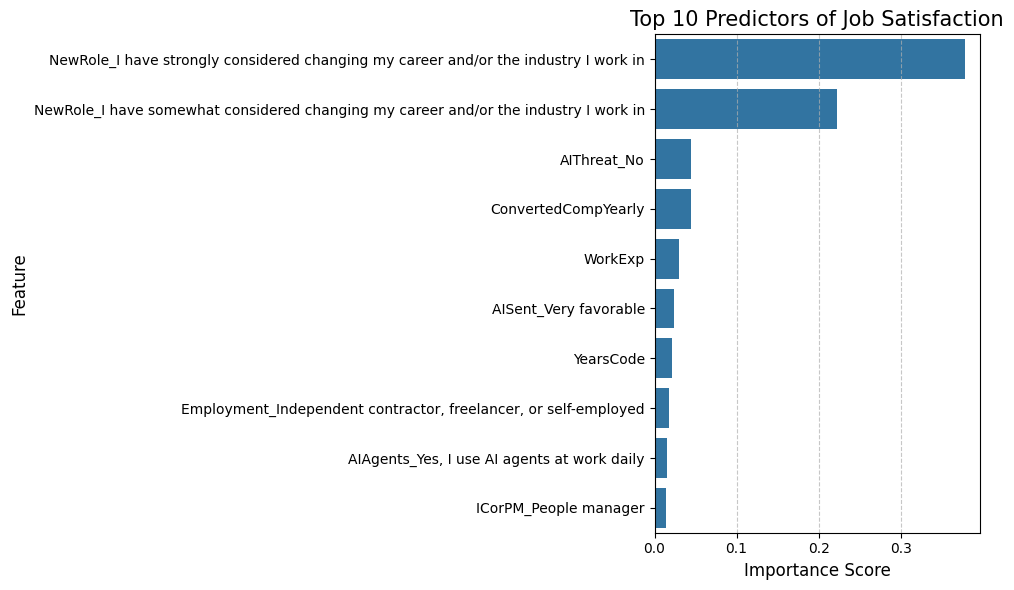

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 features
top_10_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features)

plt.title('Top 10 Predictors of Job Satisfaction', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Question 1: Does salary matter ?
Companies often use salary increases as a primary retention tool. 
We want to know if higher compensation actually correlates linearly with job satisfaction.
To address this question, we will build a linear regression to visualize the relationship.
Additionally, we will also calculate the correlation coefficient between these two parameters.

Correlation (r) for the $25k-$500k range: 0.048


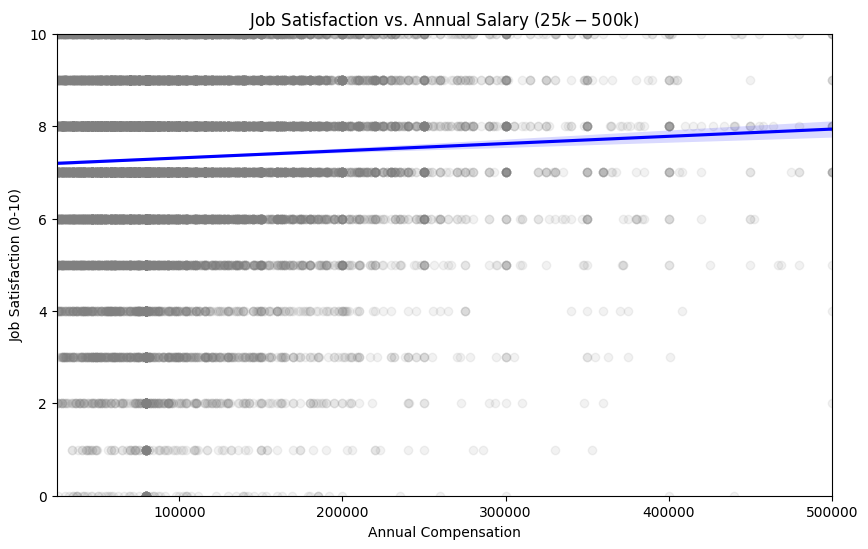

In [84]:
# 1. Define our realistic professional salary range
min_salary = 25000
max_salary = 500000

# 2. Filter the dataframe for this specific question
df_q1 = df_clean[
    (df_clean['ConvertedCompYearly'] >= min_salary) & 
    (df_clean['ConvertedCompYearly'] <= max_salary)
]

# 3. Create the visualization
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_q1, 
    x='ConvertedCompYearly', 
    y='JobSat', 
    scatter_kws={'alpha': 0.1, 'color': 'gray'}, 
    line_kws={'color': 'blue'}
)

# 4. Set strict axis limits for clarity
plt.ylim(0, 10)
plt.xlim(min_salary, max_salary)

plt.title('Job Satisfaction vs. Annual Salary ($25k - $500k)')
plt.xlabel('Annual Compensation')
plt.ylabel('Job Satisfaction (0-10)')

# Calculate the correlation coefficient (r)
r_value = df_q1['ConvertedCompYearly'].corr(df_q1['JobSat'])
print(f"Correlation (r) for the $25k-$500k range: {r_value:.3f}")

plt.show()

The correlation coefficient is very low. Which means that it is not related.
When checking the linear regression model, we see as well that there is not clear tendance.

### Question 2: The "mental exit" signal
Our model showed NewRole sentiment was the #1 predictor. We need to visualize the 
drop-off in satisfaction for those "strongly considering" a change.

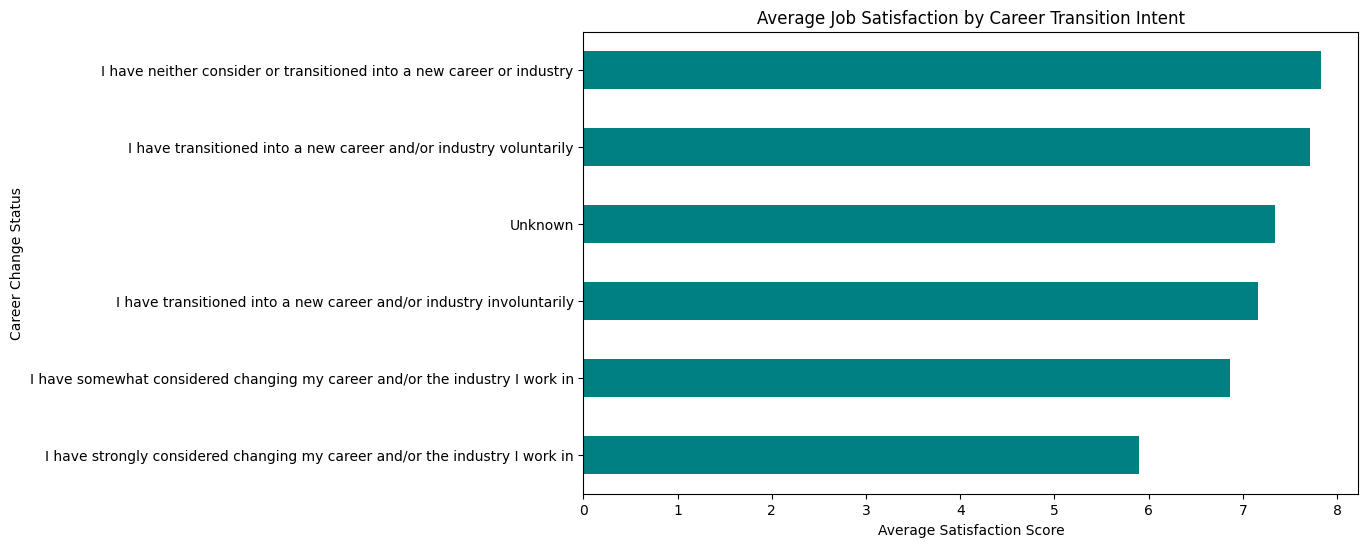

                                                                               count  \
NewRole                                                                                
I have neither consider or transitioned into a new career or industry        11544.0   
I have somewhat considered changing my career and/or the industry I work in   7386.0   
I have strongly considered changing my career and/or the industry I work in   3272.0   
I have transitioned into a new career and/or industry involuntarily            436.0   
I have transitioned into a new career and/or industry voluntarily             2079.0   
Unknown                                                                        232.0   

                                                                                 mean  \
NewRole                                                                                 
I have neither consider or transitioned into a new career or industry        7.835152   
I have somewhat considered c

In [85]:
role_sat = df_clean.groupby('NewRole')['JobSat'].mean().sort_values()

plt.figure(figsize=(10, 6))
role_sat.plot(kind='barh', color='teal')
plt.title('Average Job Satisfaction by Career Transition Intent')
plt.xlabel('Average Satisfaction Score')
plt.ylabel('Career Change Status')
plt.show()

# Table: Summary Statistics
print(df_clean.groupby('NewRole')['JobSat'].describe()[['count', 'mean', 'std']])

This time we see that when people are considering to change their career, their average satisfaction is significantly lower compared to the rest. This is confirming our assumption.

### Question 3: AI: Threat vs. Fulfillment
2026 is the year of AI integration, and the data shows that our perception of this technology is deeply tied to our workplace morale.

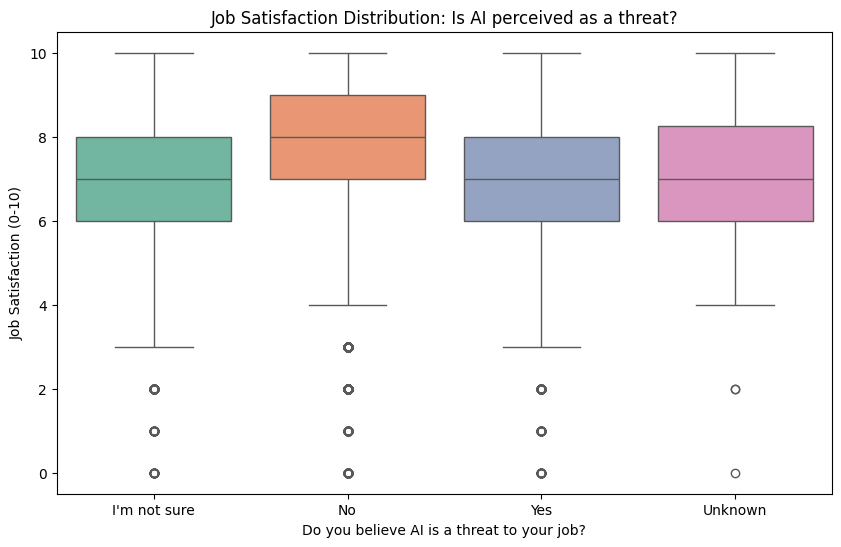

In [86]:
# --- Analyze & Visualize Question 3 ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='AIThreat', y='JobSat', hue='AIThreat', palette='Set2', legend=False)

plt.title('Job Satisfaction Distribution: Is AI perceived as a threat?')
plt.xlabel('Do you believe AI is a threat to your job?')
plt.ylabel('Job Satisfaction (0-10)')
plt.show()

The main result that we can interpret is that people who believ that AI is not a threat to their job provides on average a higher score for job satisfaction.